# Fraud Detection — Full Pipeline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE

## 1. Data Cleaning

In [4]:
df = pd.read_csv('Fraud Detection Data.csv')
df.head()

,Unnamed: 0,record_id,country,year,claim_amount_usd,policy_duration_months,previous_claims_count,reporting_delay_days,document_completeness_score,claimant_age,claim_type,seasonality_flag,amount_deviation_zscore,duplicate_claim_flag,fraud_label,fraud_probability,fraud_scheme_type,detection_method,recovery_amount_usd
0,0,1,South Africa,2024,3470.38,107,0,2,0.763,35,property,0,0.287,1,1,0.1163,inflated_claim,ml_model,1749.60
1,1,2,South Africa,2024,512.03,94,4,12,0.543,40,health,1,-1.188,0,0,0.1042,none,none,0.00
2,2,3,South Africa,2024,4450.99,82,2,6,0.625,55,travel,1,0.776,1,0,0.1512,none,none,0.00
3,3,4,South Africa,2024,4869.24,30,5,6,0.797,46,health,0,0.984,0,1,0.2996,collusion,rule_based,2803.31
4,4,5,South Africa,2024,50.00,75,0,27,0.882,40,life,0,-1.419,0,0,0.0802,none,none,0.00


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 360000 entries, 0 to 359999
Data columns (total 19 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   360000 non-null  int64  
 1   record_id                    360000 non-null  int64  
 2   country                      360000 non-null  str    
 3   year                         360000 non-null  int64  
 4   claim_amount_usd             360000 non-null  float64
 5   policy_duration_months       360000 non-null  int64  
 6   previous_claims_count        360000 non-null  int64  
 7   reporting_delay_days         360000 non-null  int64  
 8   document_completeness_score  360000 non-null  float64
 9   claimant_age                 360000 non-null  int64  
 10  claim_type                   360000 non-null  str    
 11  seasonality_flag             360000 non-null  int64  
 12  amount_deviation_zscore      360000 non-null  float64
 13  duplicate_

In [6]:
columns_to_drop = [
    'fraud_scheme_type',
    'detection_method',
    'recovery_amount_usd',
    'fraud_probability',
    'record_id',
    'Unnamed: 0'
]
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 360000 entries, 0 to 359999
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   country                      360000 non-null  str    
 1   year                         360000 non-null  int64  
 2   claim_amount_usd             360000 non-null  float64
 3   policy_duration_months       360000 non-null  int64  
 4   previous_claims_count        360000 non-null  int64  
 5   reporting_delay_days         360000 non-null  int64  
 6   document_completeness_score  360000 non-null  float64
 7   claimant_age                 360000 non-null  int64  
 8   claim_type                   360000 non-null  str    
 9   seasonality_flag             360000 non-null  int64  
 10  amount_deviation_zscore      360000 non-null  float64
 11  duplicate_claim_flag         360000 non-null  int64  
 12  fraud_label                  360000 non-null  int64  
dtypes: float64

In [7]:
df_cleaned['fraud_label'].value_counts()

fraud_label
0    310803
1     49197
Name: count, dtype: int64

In [8]:
df_cleaned.to_csv('CleandData.csv', index=False)

## 2. EDA

In [9]:
df = pd.read_csv('CleandData.csv')
df.describe()

,year,claim_amount_usd,policy_duration_months,previous_claims_count,reporting_delay_days,document_completeness_score,claimant_age,seasonality_flag,amount_deviation_zscore,duplicate_claim_flag,fraud_label
count,360000.0,360000.000000,360000.000000,360000.000000,360000.000000,360000.000000,360000.000000,360000.000000,360000.000000,360000.000000,360000.000000
mean,2024.0,1369.576297,60.603500,1.799328,14.001500,0.749950,38.248881,0.249386,0.000003,0.084511,0.136658
std,0.0,1163.213011,34.676131,1.342101,13.999602,0.144473,11.502540,0.432658,0.999996,0.278153,0.343487
min,2024.0,50.000000,1.000000,0.000000,0.000000,0.081000,18.000000,0.000000,-1.441000,0.000000,0.000000
25%,2024.0,539.180000,30.000000,1.000000,4.000000,0.659000,30.000000,0.000000,-0.803000,0.000000,0.000000
50%,2024.0,1156.300000,61.000000,2.000000,10.000000,0.771000,38.000000,0.000000,-0.059000,0.000000,0.000000
75%,2024.0,1880.930000,91.000000,3.000000,19.000000,0.862000,46.000000,0.000000,0.684000,0.000000,0.000000
max,2024.0,12021.020000,120.000000,12.000000,184.000000,1.000000,85.000000,1.000000,5.125000,1.000000,1.000000


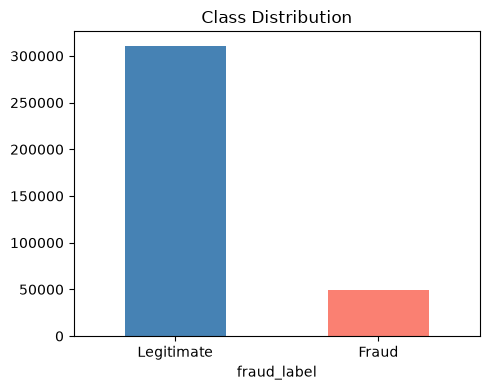

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
df['fraud_label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

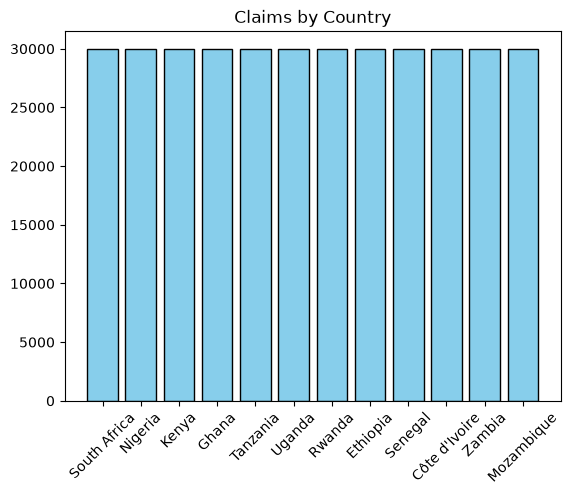

In [11]:
counts = df['country'].value_counts()
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.title('Claims by Country')
plt.show()

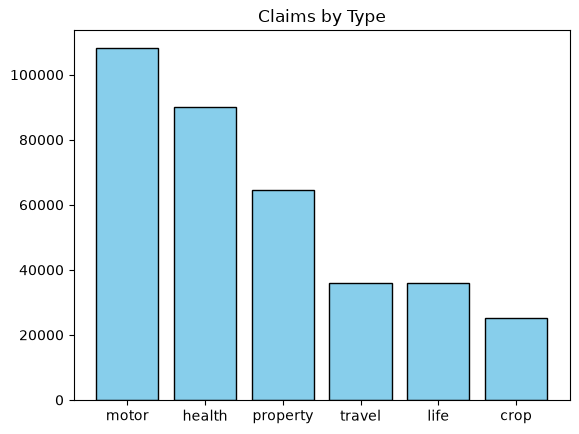

In [12]:
counts = df['claim_type'].value_counts()
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.title('Claims by Type')
plt.show()

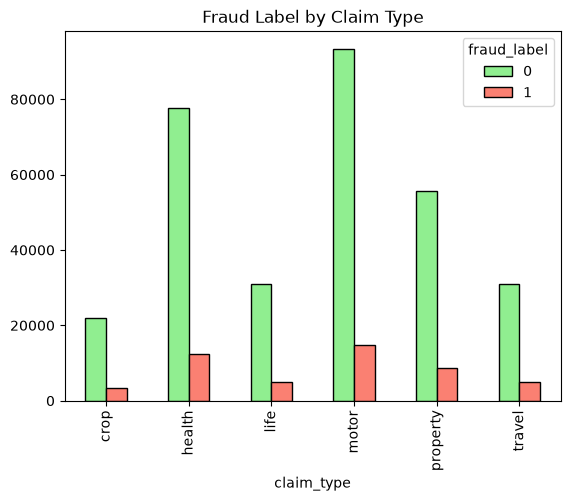

In [13]:
fraud_by_claim = pd.crosstab(df['claim_type'], df['fraud_label'])
fraud_by_claim.plot(kind='bar', color=['lightgreen', 'salmon'], edgecolor='black')
plt.title('Fraud Label by Claim Type')
plt.show()

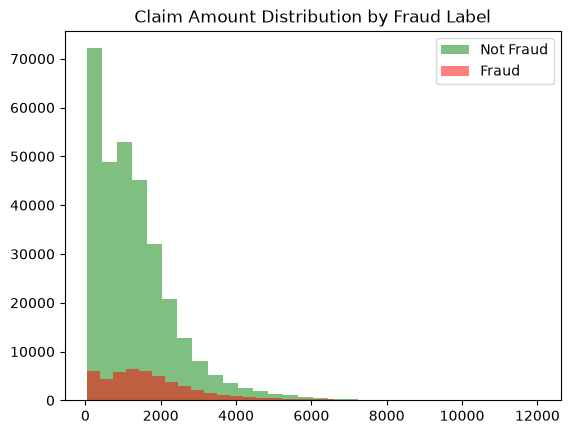

In [14]:
amount_safe  = df[df['fraud_label'] == 0]['claim_amount_usd']
amount_fraud = df[df['fraud_label'] == 1]['claim_amount_usd']
plt.hist(amount_safe,  bins=30, alpha=0.5, color='green', label='Not Fraud')
plt.hist(amount_fraud, bins=30, alpha=0.5, color='red',   label='Fraud')
plt.legend()
plt.title('Claim Amount Distribution by Fraud Label')
plt.show()

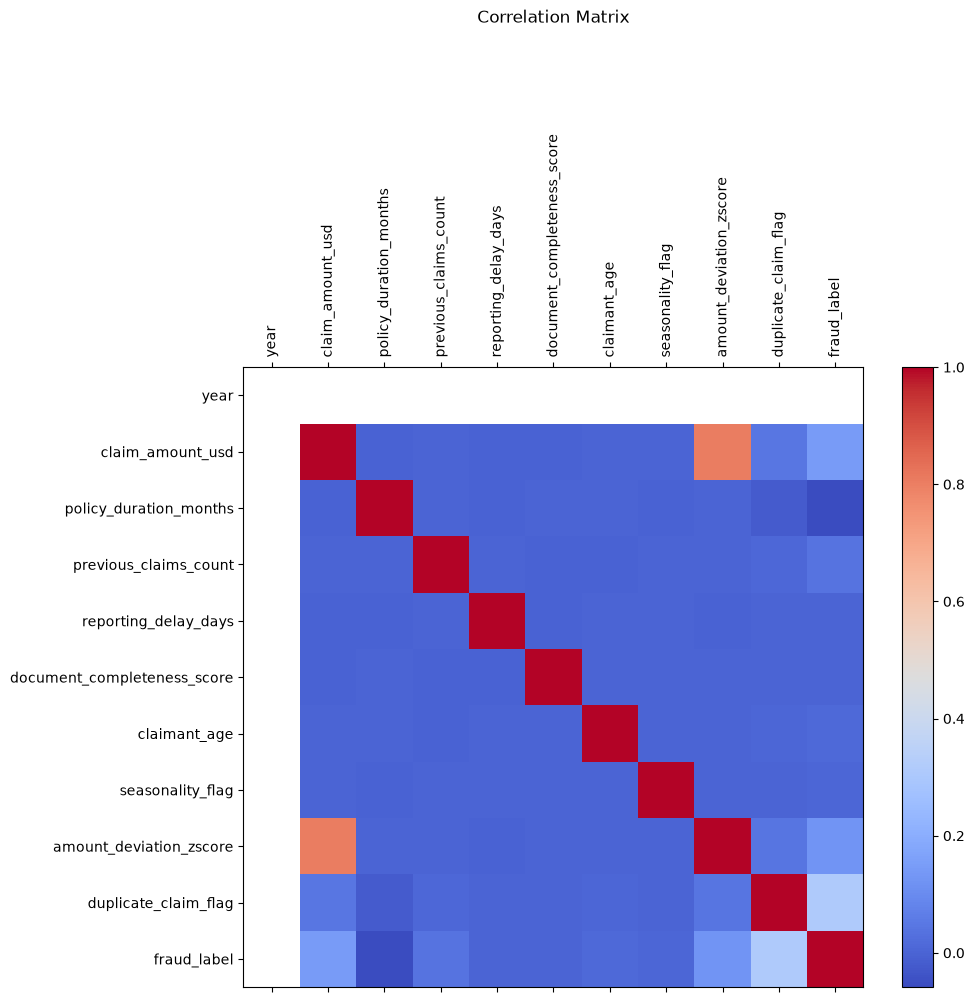

In [15]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
plt.matshow(corr_matrix, cmap='coolwarm', fignum=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Matrix', pad=80)
plt.show()

## 3. Preprocessing

In [16]:
columns_to_drop = ['year', 'claim_amount_usd']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
X = df_cleaned.drop('fraud_label', axis=1)
y = df_cleaned['fraud_label']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
cat_cols = ['country', 'claim_type']
num_cols = [col for col in X_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

In [19]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print('Before SMOTE:', dict(y_train.value_counts()))
print('After SMOTE: ', dict(pd.Series(y_train_resampled).value_counts()))

Before SMOTE: {0: np.int64(248642), 1: np.int64(39358)}
After SMOTE:  {0: np.int64(248642), 1: np.int64(248642)}


In [20]:
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump((X_train_resampled, X_test_processed, y_train_resampled, y_test), 'processed_data.pkl')

feature_names = preprocessor.get_feature_names_out()
class_names   = ['Not Fraud', 'Fraud']

## 4. Model Training

### Decision Tree

In [21]:
depth_values = range(1, 16)
test_f1_scores = []

for depth in depth_values:
    tmp = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    tmp.fit(X_train_resampled, y_train_resampled)
    test_f1_scores.append(f1_score(y_test, tmp.predict(X_test_processed)))

best_depth = list(depth_values)[test_f1_scores.index(max(test_f1_scores))]
print('Best depth:', best_depth)

Best depth: 1


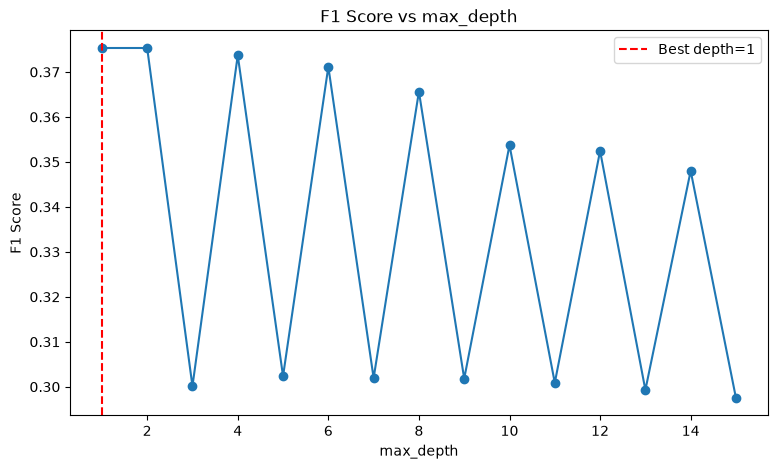

In [22]:
plt.figure(figsize=(9, 5))
plt.plot(depth_values, test_f1_scores, marker='o')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
plt.title('F1 Score vs max_depth')
plt.xlabel('max_depth')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [23]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test_processed)
print(classification_report(y_test, y_pred_dt, target_names=class_names))

              precision    recall  f1-score   support

   Not Fraud       0.90      0.95      0.92     62161
       Fraud       0.49      0.30      0.38      9839

    accuracy                           0.86     72000
   macro avg       0.69      0.63      0.65     72000
weighted avg       0.84      0.86      0.85     72000



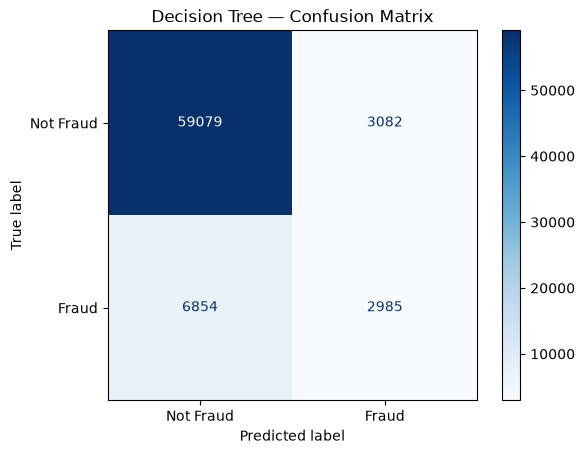

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=class_names, cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.show()

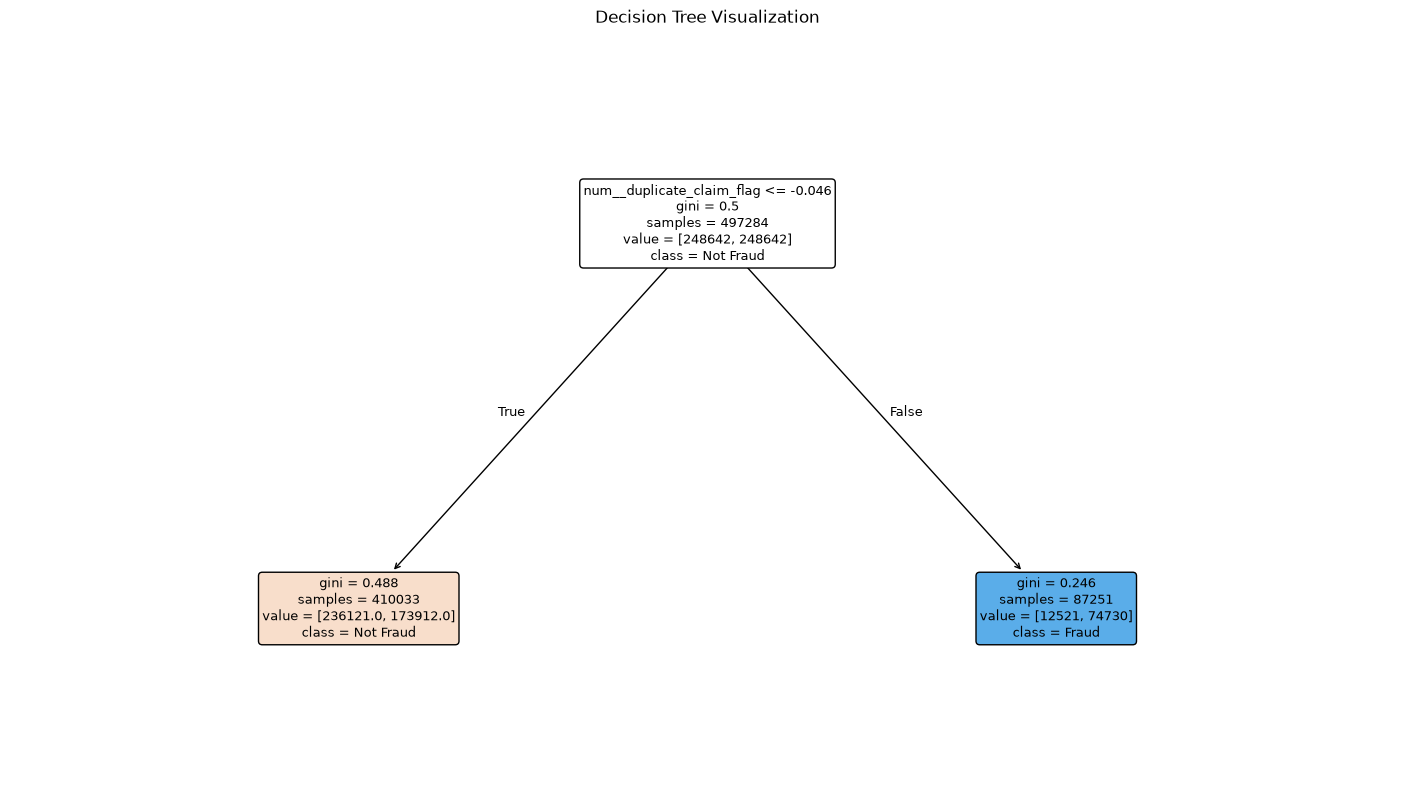

In [25]:
plt.figure(figsize=(18, 10))
plot_tree(dt_model, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree Visualization')
plt.show()

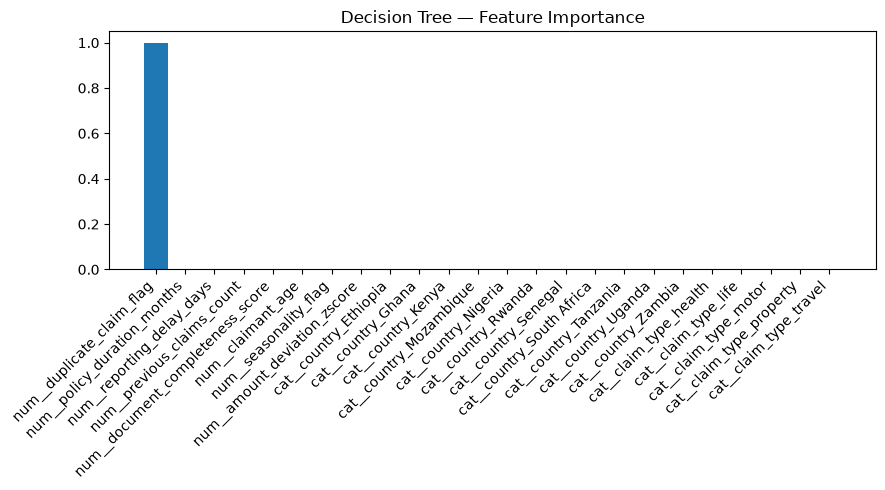

In [26]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.title('Decision Tree — Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
joblib.dump(dt_model, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

### Random Forest

In [28]:
param_dist = {
    'max_depth':    [10, 15, 20, 25, 30, None],
    'n_estimators': [50, 100, 150]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_resampled, y_train_resampled)

print('Best params:', random_search.best_params_)
rf_model = random_search.best_estimator_

Best params: {'n_estimators': 150, 'max_depth': 20}


In [29]:
y_pred_rf = rf_model.predict(X_test_processed)
print(classification_report(y_test, y_pred_rf, target_names=class_names))

              precision    recall  f1-score   support

   Not Fraud       0.90      0.90      0.90     62161
       Fraud       0.37      0.36      0.37      9839

    accuracy                           0.83     72000
   macro avg       0.63      0.63      0.63     72000
weighted avg       0.83      0.83      0.83     72000



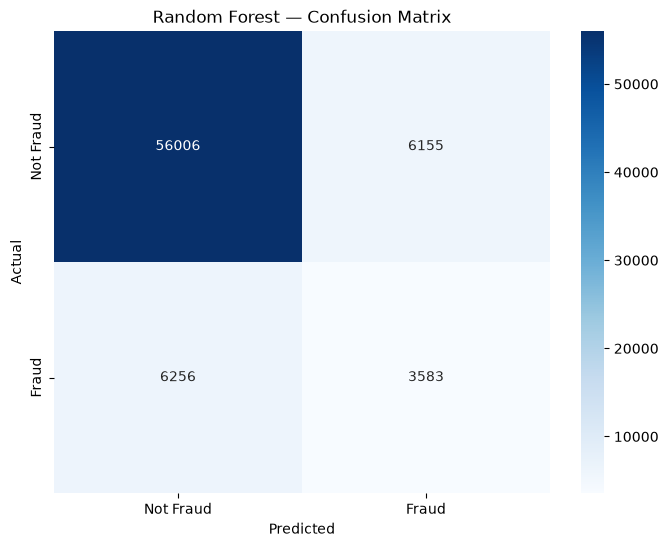

In [30]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [31]:
joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

### Linear SVM

In [32]:
svm_model = LinearSVC(random_state=42, max_iter=5000)
svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_svm = svm_model.predict(X_test_processed)
print(classification_report(y_test, y_pred_svm, target_names=class_names))

              precision    recall  f1-score   support

   Not Fraud       0.91      0.77      0.84     62161
       Fraud       0.27      0.54      0.36      9839

    accuracy                           0.74     72000
   macro avg       0.59      0.66      0.60     72000
weighted avg       0.83      0.74      0.77     72000



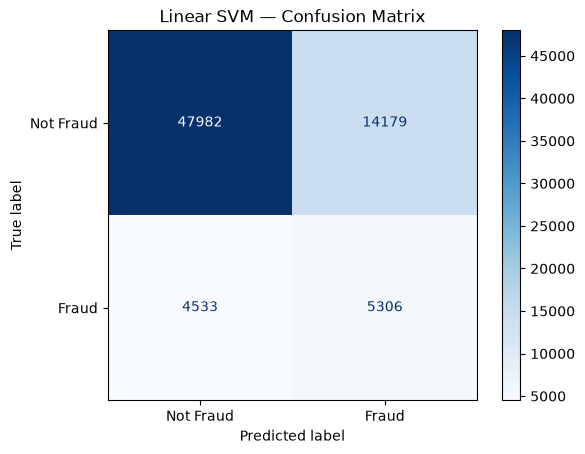

In [33]:
cm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
plt.title('Linear SVM — Confusion Matrix')
plt.show()

ROC-AUC: 0.7138


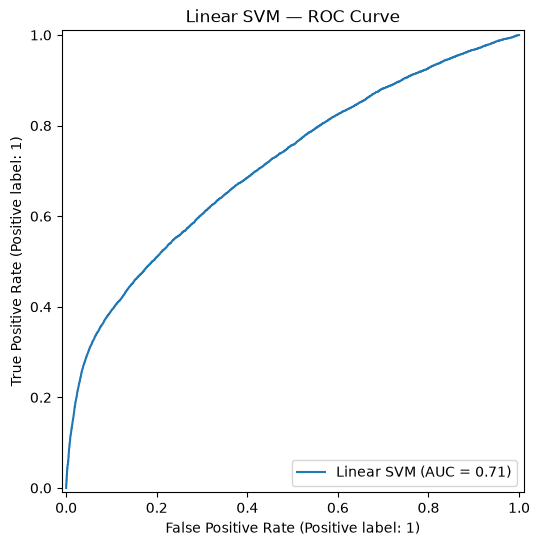

In [34]:
svm_scores = svm_model.decision_function(X_test_processed)
print(f'ROC-AUC: {roc_auc_score(y_test, svm_scores):.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, svm_scores, ax=ax, name='Linear SVM')
plt.title('Linear SVM — ROC Curve')
plt.show()

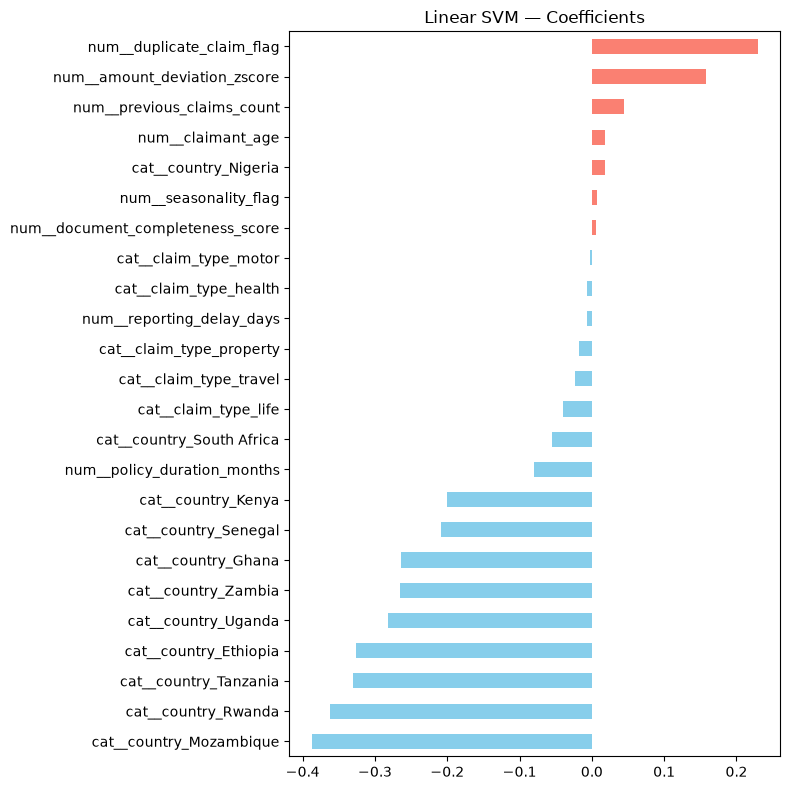

In [35]:
coefs = pd.Series(svm_model.coef_[0], index=feature_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
coefs.plot(kind='barh', ax=ax, color=['salmon' if c > 0 else 'skyblue' for c in coefs])
plt.title('Linear SVM — Coefficients')
plt.tight_layout()
plt.show()

In [36]:
joblib.dump(svm_model, 'linear_svc_fraud_model.pkl')

['linear_svc_fraud_model.pkl']

### Naive Bayes

In [37]:
nb_model = GaussianNB()
nb_model.fit(X_train_resampled, y_train_resampled)

y_pred_nb = nb_model.predict(X_test_processed)
print(classification_report(y_test, y_pred_nb, target_names=class_names))

              precision    recall  f1-score   support

   Not Fraud       0.91      0.76      0.83     62161
       Fraud       0.25      0.52      0.34      9839

    accuracy                           0.73     72000
   macro avg       0.58      0.64      0.58     72000
weighted avg       0.82      0.73      0.76     72000



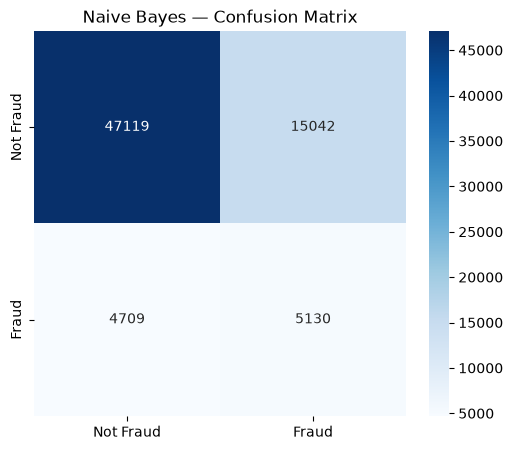

In [38]:
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Naive Bayes — Confusion Matrix')
plt.show()

In [39]:
joblib.dump(nb_model, 'naive_bayes_model.pkl')

['naive_bayes_model.pkl']

## 5. Model Comparison

In [40]:
results = []

for name, y_pred in [
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf),
    ('Linear SVM',    y_pred_svm),
    ('Naive Bayes',   y_pred_nb)
]:
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.8620,0.4920,0.3034,0.3753
1,Random Forest,0.8276,0.3679,0.3642,0.3660
2,Linear SVM,0.7401,0.2723,0.5393,0.3619
3,Naive Bayes,0.7257,0.2543,0.5214,0.3419


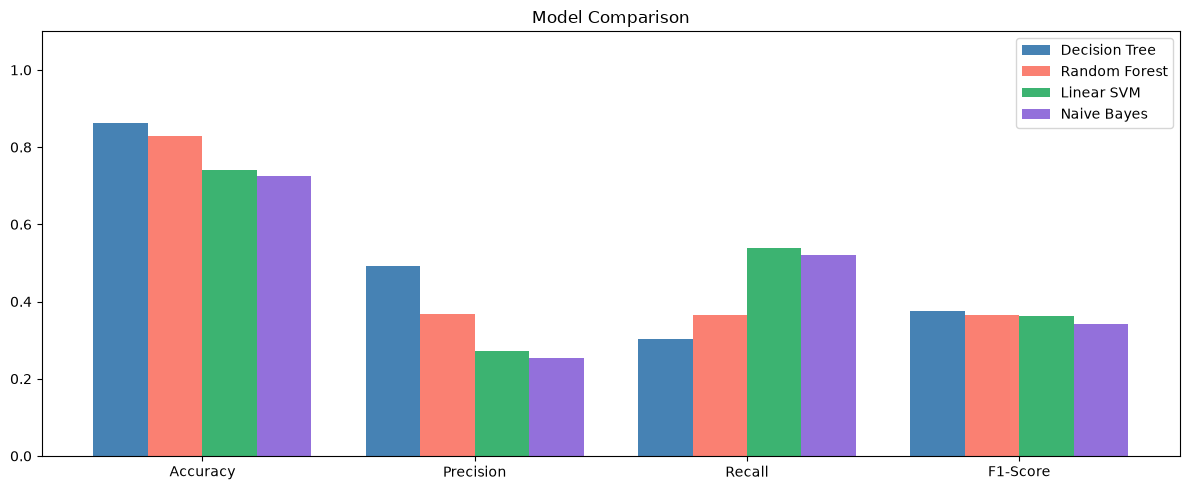

In [41]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.2
colors = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row['Model'], color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()